# Assignment 7.1 — Choosing the Right Metric

You have one data file, `match_predictions.csv`, with 1,000 games. Each row gives:

| column | meaning |
|---|---|
| `game_id` | identifier for the game |
| `prob_model_A` | Model A's predicted probability that **blue** wins |
| `prob_model_B` | Model B's predicted probability that blue wins |
| `prob_model_C` | Model C's predicted probability that blue wins |
| `bwin` | the actual outcome: `1` if blue won, `0` if blue lost |

The three models were each tuned to maximize a *different* metric. Your task is to decide which model the betting house should deploy to maximize profit, and to defend that choice in terms of money, not metrics.

This notebook gives you the scaffolding: loading the data, the three metrics, the quote formula, and a settlement rule. The **conclusions are yours to write.** Wherever you see a *Question* in bold, that is something to answer in your writeup.

## 1. Setup and data

Load the file and pull out the pieces we'll reuse: the actual outcomes `y`, and a dictionary of each model's predicted probabilities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score

In [2]:
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/newman_ml_ops/week7/match_predictions.csv")   # adjust the path if needed
df.head()

Mounted at /content/drive


,game_id,prob_model_A,prob_model_B,prob_model_C,bwin
0,1,0.4503,0.4924,0.4966,1
1,2,0.5255,0.4900,0.4075,0
2,3,0.5519,0.6131,0.6602,1
3,4,0.5026,0.3869,0.4641,1
4,5,0.5276,0.4988,0.4690,0


In [3]:
y = df["bwin"].values   # actual outcomes: 1 = blue won, 0 = blue lost

# Each model's predicted P(blue wins), keyed by model name
models = {
    "A": df["prob_model_A"].values,
    "B": df["prob_model_B"].values,
    "C": df["prob_model_C"].values,
}

print(f"{len(df)} games, blue won {y.mean():.1%} of them")

1000 games, blue won 52.0% of them


## 2. The three evaluation metrics

Each model was tuned for one of these. Before thinking about profit, make sure you understand what each metric actually measures: they reward different things, and that difference is the heart of the assignment.

- **AUC** uses the raw probabilities but only cares about *ranking*: does the model give higher scores to games blue actually won? It never looks at whether a probability is *numerically* right, only whether the order is right. A model can have good AUC while being systematically over- or under-confident.
- **Brier score** is the mean squared error between the predicted probability and the outcome. It is the only one of the three that punishes a probability for being *miscalibrated*: predicting 0.9 on a game that is lost costs far more than predicting 0.6. Lower is better.
- **Accuracy** ignores the probability entirely once you threshold it at 0.5. It asks only: did the model call the right winner? A confident-but-wrong 0.95 and a barely-wrong 0.51 are penalized identically.

**Question 1.** Compute each of them for each of the models in the cell below:

In [4]:
print(f"{'Model':6}{'AUC':>9}{'Brier':>9}{'Accuracy':>11}")


Model       AUC    Brier   Accuracy


In [5]:
def auc_score(y_true, y_prob):
    pos = y_prob[y_true == 1]
    neg = y_prob[y_true == 0]

    comparisons = pos[:, None] - neg[None, :]
    wins = np.sum(comparisons > 0)
    ties = np.sum(comparisons == 0)

    return (wins + 0.5 * ties) / (len(pos) * len(neg))


def brier_score(y_true, y_prob):
    return np.mean((y_prob - y_true) ** 2)


def accuracy_score(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return np.mean(y_pred == y_true)


y = df["bwin"].to_numpy()

results = []

for col in ["prob_model_A", "prob_model_B", "prob_model_C"]:
    p = df[col].to_numpy()

    results.append({
        "Model": col.replace("prob_", ""),
        "AUC": auc_score(y, p),
        "Brier": brier_score(y, p),
        "Accuracy": accuracy_score(y, p),
    })

metrics = pd.DataFrame(results)

print(metrics.to_string(index=False, float_format="{:.3f}".format))

  Model   AUC  Brier  Accuracy
model_A 0.561  0.249     0.557
model_B 0.580  0.247     0.551
model_C 0.578  0.244     0.556


**Question 2.** Read the cell above. No single model is best on all three metrics. Which model wins on each metric? State, in your own words, what each metric is rewarding that the others are not. *(This is Part 1 of the written assignment.)*

### Question 2 Response
AUC is concerned with whether results that occurred had higher predicted probabilities than those that did not occur. Model B with the highest AUC would be best used when ranking the likely outcomes. Those at the top and bottom of the range would be the  most and least likely to occur respectively.

Brier score measures how accurate the predicted probabilities are. A high-probability prediction that does not occur is penalized more than a lower-probability prediction that does not occur. From the video, we're going to be looking at probabilities, odds, and house betting profit. Without reading ahead (or coming back to correct) I anticipate that Model C with the lowest Brier score will have the best profitability metric.

Accuracy is a pure measurement of how well the model predicts the outcome regardless of predicted probabilities. It rewards accurate predictions equally. Model A has the best accuracy metric.

## 3. From probability to a quote

The betting house turns a predicted probability into **decimal odds** (a "quote") with this formula:

$$\text{odds} = \frac{1}{p + \text{margin}}$$

where `p` is the model's predicted probability for the side being quoted, and `margin` (here 0.05) is the house's built-in edge. Decimal odds mean: stake 1 unit (bet 1 dollar on an outcome), and if you win you receive `odds` units back (you receive `odds` dollars back). Your net gain would be `odds − 1` dollars.

In [6]:
def quote(p, margin=0.05):
    """Decimal odds the house offers, given a predicted probability p."""
    return 1.0 / (p + margin)

# See how the quote changes with confidence:
for p in [0.50, 0.65, 0.85]:
    print(f"p = {p:.2f}  ->  odds = {quote(p):.3f}   (net payout if it wins: {quote(p)-1:.3f})")

p = 0.50  ->  odds = 1.818   (net payout if it wins: 0.818)
p = 0.65  ->  odds = 1.429   (net payout if it wins: 0.429)
p = 0.85  ->  odds = 1.111   (net payout if it wins: 0.111)


Notice the direction: the **more** confident the model is that blue wins, the **shorter** the odds (smaller payout).

**Question 3.** The margin is the only reason the odds are not "fair." What would fair odds be at `p = 0.5` with no margin, and how does the margin change them? In one sentence, explain where the house's structural edge comes from.

### Question 3 Response
Fair odds with no margin at p = 0.5 would be 2. With a 50-50 chance of a win/loss paying double for a win or lossing everything are fair odds. Margin incrementally lowers the payout in a win scenario. The house edge comes from paying winners slightly less than fair value while still collecting the full wagered amount from losers.

## 4. Settling a game: quote + outcome = profit

A quote on its own is not profit: it is only a *promise to pay*. Profit depends on what actually happened. Use this settlement rule for the whole assignment:

> The house prices **blue** for every game using that game's predicted probability. One unit is staked on blue each game.
> - If blue **wins**, the house must pay out at the quoted odds, so it nets `1 - odds` (a loss, since odds > 1).
> - If blue **loses**, the house keeps the 1-unit stake, netting `+1`.

You will compute this yourself in Question 4 below. Note that it needs *both* the probabilities (to set the quote) and `y` (to know what happened)

 **Question 4.** Using the quote formula from Section 3, compute for each model A, B, and C:
 - (a) the odds the house would offer on blue for every game
 - (b) the house's total profit in units across all 1,000 games

In [7]:
df["odds_model_A"] = quote(df["prob_model_A"])
df["odds_model_B"] = quote(df["prob_model_B"])
df["odds_model_C"] = quote(df["prob_model_C"])

print(df)

     game_id  prob_model_A  prob_model_B  prob_model_C  bwin  odds_model_A  \
0          1        0.4503        0.4924        0.4966     1      1.998801   
1          2        0.5255        0.4900        0.4075     0      1.737619   
2          3        0.5519        0.6131        0.6602     1      1.661406   
3          4        0.5026        0.3869        0.4641     1      1.809627   
4          5        0.5276        0.4988        0.4690     0      1.731302   
..       ...           ...           ...           ...   ...           ...   
995      996        0.4676        0.4921        0.4767     0      1.931994   
996      997        0.4210        0.4759        0.4840     0      2.123142   
997      998        0.5561        0.5392        0.4731     0      1.649893   
998      999        0.3934        0.5088        0.5386     1      2.255300   
999     1000        0.5262        0.3869        0.4798     1      1.735509   

     odds_model_B  odds_model_C  
0        1.843658      1.8294

In [8]:
for model in ["A", "B", "C"]:
    odds_col = f"odds_model_{model}"
    house_profit_col = f"house_profit_model_{model}"

    df[house_profit_col] = np.where(
        df["bwin"] == 1,
        -(df[odds_col] - 1),
        1
    )

print(df)

     game_id  prob_model_A  prob_model_B  prob_model_C  bwin  odds_model_A  \
0          1        0.4503        0.4924        0.4966     1      1.998801   
1          2        0.5255        0.4900        0.4075     0      1.737619   
2          3        0.5519        0.6131        0.6602     1      1.661406   
3          4        0.5026        0.3869        0.4641     1      1.809627   
4          5        0.5276        0.4988        0.4690     0      1.731302   
..       ...           ...           ...           ...   ...           ...   
995      996        0.4676        0.4921        0.4767     0      1.931994   
996      997        0.4210        0.4759        0.4840     0      2.123142   
997      998        0.5561        0.5392        0.4731     0      1.649893   
998      999        0.3934        0.5088        0.5386     1      2.255300   
999     1000        0.5262        0.3869        0.4798     1      1.735509   

     odds_model_B  odds_model_C  house_profit_model_A  house_pr

In [9]:
for model in ["A", "B", "C"]:
    profit_col = f"house_profit_model_{model}"
    total_profit = df[profit_col].sum()
    print(f"Total profit for Model {model}: {total_profit:.2f}")

Total profit for Model A: 46.32
Total profit for Model B: 57.94
Total profit for Model C: 63.78


**Question 5.** Which model is most profitable for the house under this rule? Connect your answer back to the metrics table in Section 2: the most profitable model is the one that was best on *which* metric? Why would that metric, rather than the others, be the one that drives profit here?

### Question 5 Response
Model C is most profitable for the house, and it is also the model with the best Brier score. That makes sense because this is an odds-setting problem: the house is not just picking winners, it is turning probabilities into payout prices. Brier score rewards probabilities that are numerically close to the actual outcomes, while AUC only rewards ranking and accuracy only rewards the 0.5 decision. The costly failure here is a badly calibrated probability, especially when the model assigns a low probability to blue, offers long odds, and blue actually wins. In that case the house has to pay a large payout. Model C’s better Brier score means its probabilities are better calibrated, so its quotes are safer and more profitable.

**Question 6.** Look at the games where the most-profitable and least-profitable models diverge most. Without naming specific games, describe what *kind* of game costs the worst model the most and tie that back to what its metric failed to capture.

*Hint: look at games where one model predicted a probability far from 0.5 and was wrong. The `quote` formula tells you what the house had to pay on those.*

### Question 6 Response
The worst model is hurt most on games where it assigns a probability far below 0.5 to an outcome that actually occurs. Because the quote formula gives higher odds when the predicted probability is lower, the house offers a large payout on an event the model thought was unlikely. When that event happens, the house has to pay much more than it would have under a better-calibrated model. This ties back to the metric it failed on because accuracy/AUC can miss the size of the probability error: they may reward correct classifications or rankings, but they do not punish a confidently wrong probability in the same way profitability does.

## 5. From metric to organization

Everything above produces evidence. The written assignment asks you to turn it into a decision. In your writeup, move from these numbers to the three questions the course has carried since Week 1:

1. **Deployment**: Is a model with these metrics good enough to actually deploy? Good enough *for what*, specifically?
2. **Maintenance**: Performance shifts at every game patch, and retraining has a cost. What retraining policy would you propose, and what would you monitor?
3. **ROI**: Put it together: make the case to management that deploying your chosen model is worth it, or argue honestly that it is not.

### Part 5 Response
When measuring models from a business perspective the primary metric will be profitability. If controlling for other variables then more profit is better than less and some is better than none. We can't determine if a model is good enough to deploy without comparing it with the alternatives. Model C is the best candidate to deploy from the three tested models because it produces the highest simulated profit and has the best Brier score, which matters for pricing. I would not treat this as proof that it is ready for full production by itself, but it is good enough for a controlled deployment or shadow test against the current odds setting process.

As with the first question, the question of maintenance requires assumptions. I assume the house needs to continue offering League of Legends bets through patch updates, so I would not pause the book after every patch. Instead, I would monitor performance by patch and run candidate models in shadow mode. Because this is an odds-setting problem, the primary monitoring metrics should be profit per game, Brier score, and calibration error. AUC and accuracy are useful secondary metrics, but they do not directly measure whether the quoted probabilities are correctly priced. After each patch, I would compare the production Model C against one or more retrained shadow models on new post-patch games. I would promote a shadow model only when it shows a meaningful improvement in profit and calibration over a sufficient monitoring window. This avoids retraining blindly just because a patch occurred, while still responding when a patch actually changes the relationship between model probabilities and game outcomes.

For ROI I'll go back to the answer for the first question. It's relative but I'll assume that we have no existing business in this area but that there is sufficient adjacent activity that we're not starting entirely from zero. An established book would run millions of dollars a month with thousands of dollars in expenses. Let's start with a base case of \$1M in monthly wagers with our 6% revenue from Model C. That's \$60K per month in cashflow. That would support a full time employee like a staff data scientist plus sufficient technical leadership from a principal data scientist with expenses for equipment and could still yield a \$30K per month profit. With the low marginal expenses of this type of business there is substantial opportunity to materially increase stockholder returns as the monthly handle scales.

### Maintenance Analysis

In [10]:
def model_metrics_for_group(group, model):
    p = group[f"prob_model_{model}"].to_numpy()
    y = group["bwin"].to_numpy()

    odds = quote(p)
    profit = np.where(y == 1, -(odds - 1), 1)

    # AUC is undefined if the group contains only one class
    auc = np.nan
    if len(np.unique(y)) == 2:
        auc = auc_score(y, p)

    return pd.Series({
        "games": len(group),
        "blue_win_rate": y.mean(),
        "avg_pred_prob": p.mean(),
        "calibration_error": p.mean() - y.mean(),
        "auc": auc,
        "brier": brier_score(y, p),
        "accuracy": accuracy_score(y, p),
        "total_profit": profit.sum(),
        "profit_per_game": profit.mean(),
    })


# Use game_id order as a proxy for time/patch sequence.
# In production, replace this with the actual patch column.
df = df.sort_values("game_id").copy()
df["monitoring_window"] = (np.arange(len(df)) // 100) + 1

monitoring_results = []

for model in ["A", "B", "C"]:
    temp = (
        df.groupby("monitoring_window")
          .apply(lambda g: model_metrics_for_group(g, model))
          .reset_index()
    )
    temp["model"] = model
    monitoring_results.append(temp)

monitoring = pd.concat(monitoring_results, ignore_index=True)

display(monitoring)

/tmp/ipykernel_5086/130468836.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: model_metrics_for_group(g, model))
/tmp/ipykernel_5086/130468836.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: model_metrics_for_group(g, model))
/tmp/ipykernel_5086/130468836.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

,monitoring_window,games,blue_win_rate,avg_pred_prob,calibration_error,auc,brier,accuracy,total_profit,profit_per_game,model
0,1,100.0,0.56,0.494807,-0.065193,0.523133,0.254364,0.55,-4.570184,-0.045702,A
1,2,100.0,0.46,0.493005,0.033005,0.470612,0.263110,0.53,11.852244,0.118522,A
2,3,100.0,0.51,0.508211,-0.001789,0.620648,0.238822,0.60,8.777395,0.087774,A
3,4,100.0,0.58,0.508886,-0.071114,0.582923,0.245765,0.59,-5.249976,-0.052500,A
4,5,100.0,0.47,0.494862,0.024862,0.581092,0.247037,0.61,12.796437,0.127964,A
5,6,100.0,0.52,0.511890,-0.008110,0.537660,0.251367,0.51,5.461740,0.054617,A
6,7,100.0,0.54,0.517424,-0.022576,0.585950,0.242755,0.56,4.760177,0.047602,A
7,8,100.0,0.54,0.499975,-0.040025,0.534823,0.255103,0.49,-0.715368,-0.007154,A
8,9,100.0,0.52,0.500364,-0.019636,0.563101,0.248209,0.56,4.463677,0.044637,A
9,10,100.0,0.50,0.498495,-0.001505,0.597800,0.243459,0.57,8.748226,0.087482,A


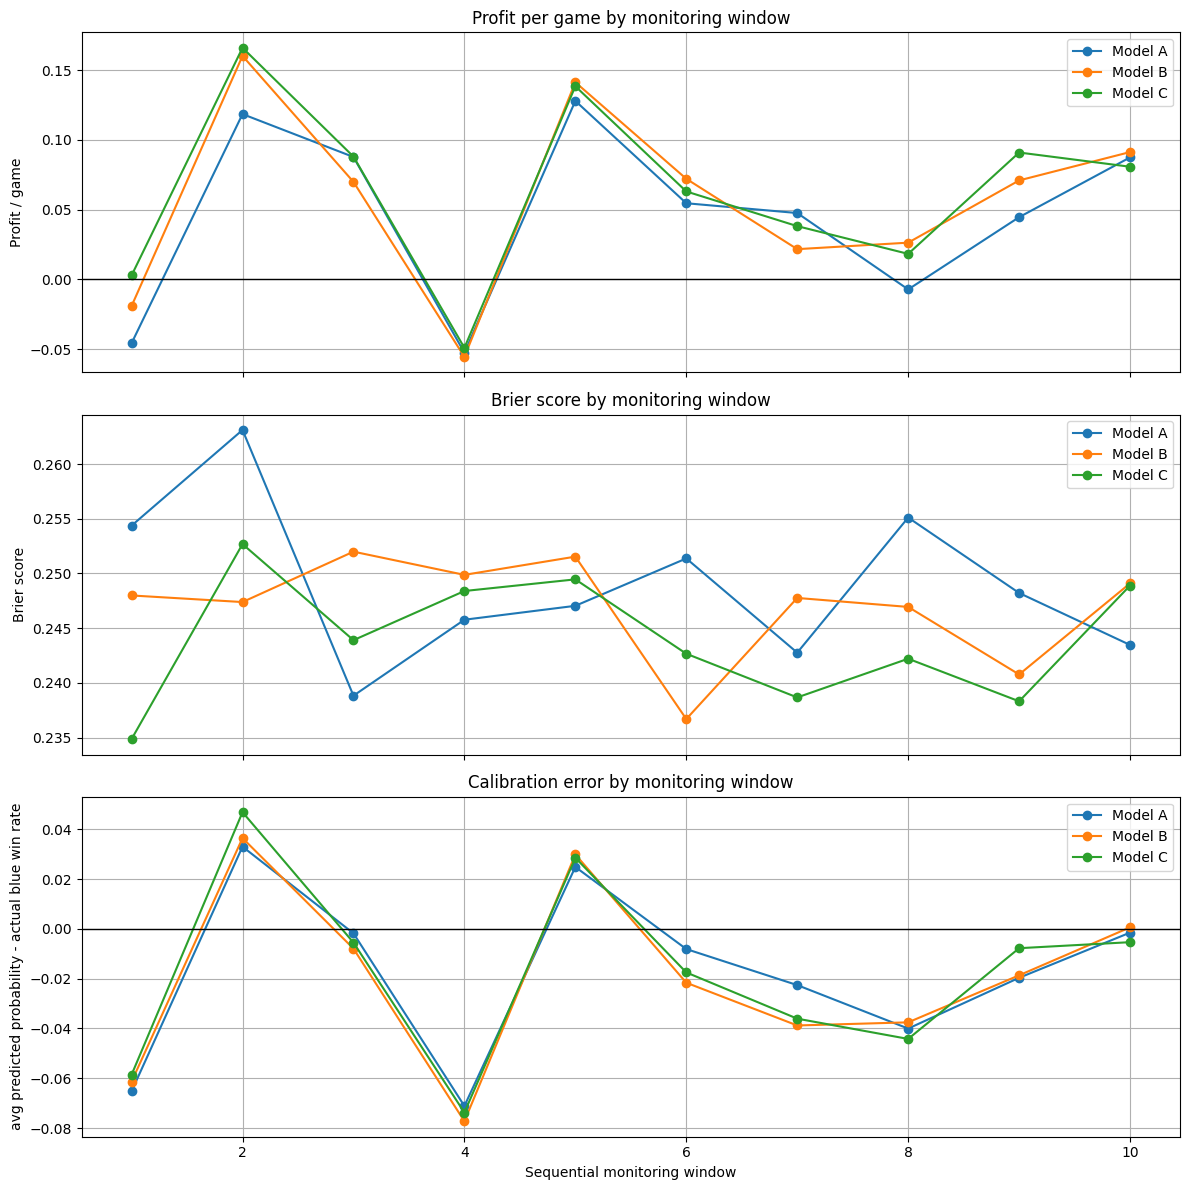

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for model in ["A", "B", "C"]:
    m = monitoring[monitoring["model"] == model]

    axes[0].plot(m["monitoring_window"], m["profit_per_game"], marker="o", label=f"Model {model}")
    axes[1].plot(m["monitoring_window"], m["brier"], marker="o", label=f"Model {model}")
    axes[2].plot(m["monitoring_window"], m["calibration_error"], marker="o", label=f"Model {model}")

axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Profit per game by monitoring window")
axes[0].set_ylabel("Profit / game")

axes[1].set_title("Brier score by monitoring window")
axes[1].set_ylabel("Brier score")

axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Calibration error by monitoring window")
axes[2].set_ylabel("avg predicted probability - actual blue win rate")
axes[2].set_xlabel("Sequential monitoring window")

for ax in axes:
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()